# Benchmark Forecasting Models

## Part 2 & Part 3 – Forecasting Problem Definition and Benchmark Models

This notebook defines the forecasting problem and establishes baseline forecasting models for appliance energy consumption.

Benchmark models provide a reference point against which more advanced forecasting methods, including SARIMAX, machine learning models, and foundation models, will later be compared.

The benchmark models implemented are:

- Mean Forecast
- Naïve Forecast
- Daily Seasonal Naïve Forecast
- Weekly Seasonal Naïve Forecast
- Drift Forecast

## 1. Import Required Libraries

The required Python libraries are imported for loading the processed dataset, visualisation, model evaluation, and implementation of benchmark forecasting methods.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load the Processed Hourly Dataset

The cleaned hourly dataset produced during Part 1 is loaded.

All forecasting models use exactly the same dataset to ensure fair comparison.

In [2]:
df = pd.read_csv(
    "../data/hourly_energy_data.csv",
    parse_dates=["date"],
    index_col="date"
)

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Hour,Weekday
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044,17,Monday
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206,18,Monday
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932,19,Monday
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642,20,Monday
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274,21,Monday


## 3. Forecasting Problem Definition

The objective is to forecast hourly appliance energy consumption.

### Target Variable

The response variable is:

- **Appliances**

### Forecast Horizon

The forecasting horizon is **24 hours**, meaning each model predicts appliance energy demand for the next 24 hourly observations.

### Train/Test Split

Following the assignment specification, the final **14 days** of observations are reserved for testing.

The remaining observations are used for model training.

This chronological split preserves the temporal ordering of the data and prevents information leakage.

### Evaluation Metrics

Model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- Coefficient of Determination (R²)

These metrics capture prediction accuracy from complementary perspectives.

## 4. Train-Test Split

A chronological split is used rather than a random split because forecasting models must always predict future observations from historical information.

The last **14 days (336 hours)** are reserved for testing.

In [3]:
forecast_horizon = 24

test_days = 14

test_size = test_days * 24

train = df.iloc[:-test_size].copy()

test = df.iloc[-test_size:].copy()

print("Training observations :", len(train))
print("Testing observations  :", len(test))

Training observations : 2954
Testing observations  : 336


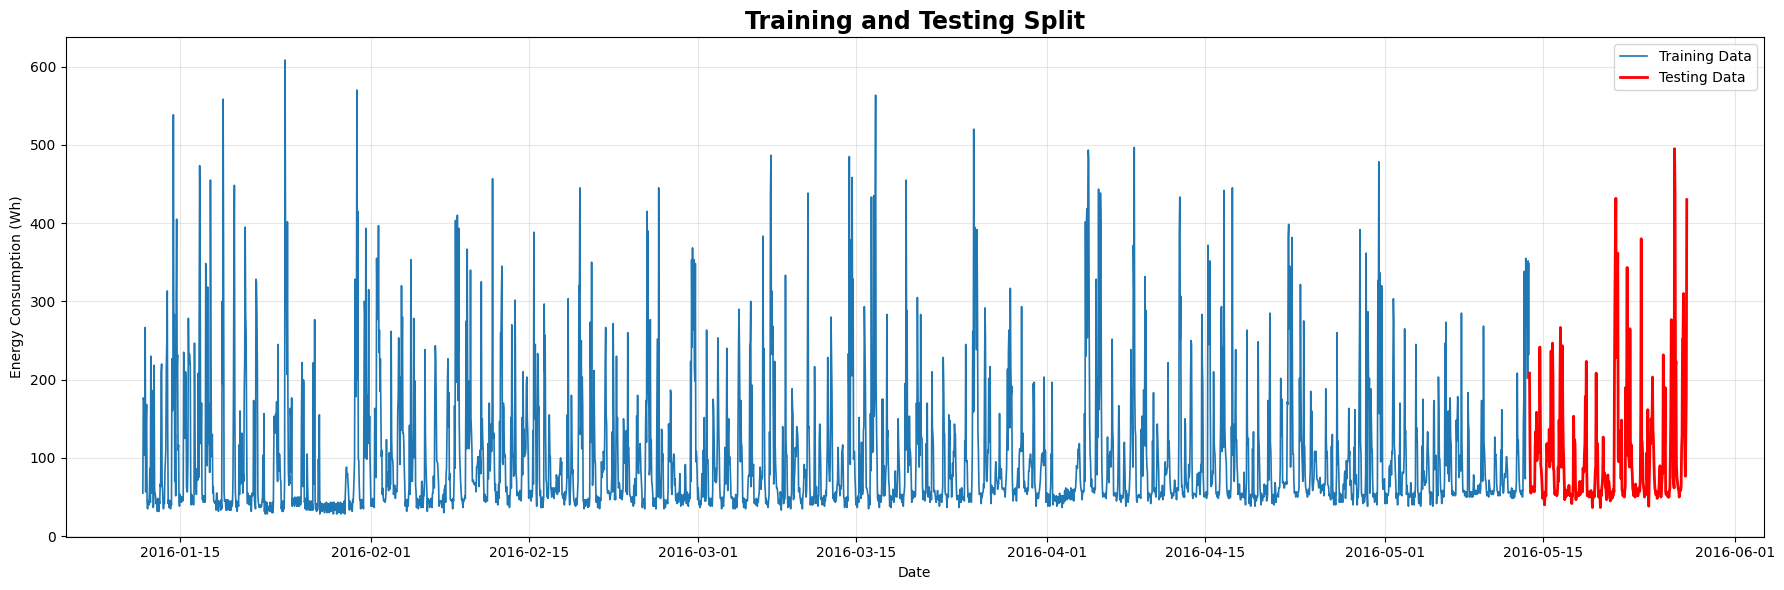

In [4]:
plt.figure(figsize=(18,6))

plt.plot(
    train.index,
    train["Appliances"],
    label="Training Data",
    linewidth=1.2
)

plt.plot(
    test.index,
    test["Appliances"],
    label="Testing Data",
    linewidth=2,
    color="red"
)

plt.title(
    "Training and Testing Split",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Energy Consumption (Wh)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig("../outputs/figures/train_test_split.png", dpi=300)

plt.show()

## 5. Evaluation Function

A reusable evaluation function is defined to compute common forecasting accuracy metrics.

Using a single evaluation function ensures consistency across all forecasting models.

In [5]:
def evaluate_forecast(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = (
        np.mean(
            np.abs((actual - predicted) / actual)
        )
    ) * 100

    r2 = r2_score(actual, predicted)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

## 6. Benchmark Forecasting Models

Benchmark forecasting models provide simple reference points against which more advanced forecasting approaches can be compared.

Five benchmark methods are implemented:

- Mean Forecast
- Naïve Forecast
- Daily Seasonal Naïve Forecast
- Weekly Seasonal Naïve Forecast
- Drift Forecast

Each model is evaluated using a rolling-origin forecasting strategy with a **24-hour forecast horizon** over the final 14 days of data.

In [6]:
forecast_horizon = 24


def walk_forward_validation(series, model_name):
    
    predictions = []
    actuals = []
    
    history = list(train["Appliances"])

    test_values = test["Appliances"].values

    for start in range(0, len(test_values), forecast_horizon):

        actual_block = test_values[start:start+forecast_horizon]

        horizon = len(actual_block)

        # -------------------------
        # Mean Forecast
        # -------------------------

        if model_name == "Mean":

            forecast = [np.mean(history)] * horizon

        # -------------------------
        # Naive Forecast
        # -------------------------

        elif model_name == "Naive":

            forecast = [history[-1]] * horizon

        # -------------------------
        # Daily Seasonal Naive
        # -------------------------

        elif model_name == "Daily":

            forecast = history[-24:][:horizon]

        # -------------------------
        # Weekly Seasonal Naive
        # -------------------------

        elif model_name == "Weekly":

            forecast = history[-168:][:horizon]

        # -------------------------
        # Drift
        # -------------------------

        elif model_name == "Drift":

            drift = (
                history[-1] - history[0]
            ) / (len(history)-1)

            forecast = [
                history[-1] + drift*(i+1)
                for i in range(horizon)
            ]

        predictions.extend(forecast)

        actuals.extend(actual_block)

        history.extend(actual_block)

    return np.array(actuals), np.array(predictions)

The benchmark models are evaluated using walk-forward validation.

After each 24-hour forecast, the observed values are incorporated into the historical data before producing the next forecast.

This procedure closely simulates a real-world forecasting environment where newly observed data become available over time.

In [7]:
actual_mean, pred_mean = walk_forward_validation(
    df,
    "Mean"
)

mean_metrics = evaluate_forecast(
    actual_mean,
    pred_mean
)

mean_metrics

{'MAE': 50.25809156123767,
 'RMSE': np.float64(74.938304240935),
 'MAPE': np.float64(53.695620425245984),
 'R2': -0.0025968361468065027}

In [8]:
actual_naive, pred_naive = walk_forward_validation(
    df,
    "Naive"
)

naive_metrics = evaluate_forecast(
    actual_naive,
    pred_naive
)

naive_metrics

{'MAE': 85.55059523809524,
 'RMSE': np.float64(110.38970919802894),
 'MAPE': np.float64(112.91066495866757),
 'R2': -1.1755836466846992}

In [9]:
actual_daily, pred_daily = walk_forward_validation(
    df,
    "Daily"
)

daily_metrics = evaluate_forecast(
    actual_daily,
    pred_daily
)

daily_metrics

{'MAE': 48.30853174603175,
 'RMSE': np.float64(85.56471876821426),
 'MAPE': np.float64(43.32691008021383),
 'R2': -0.30709773366885673}

In [10]:
actual_weekly, pred_weekly = walk_forward_validation(
    df,
    "Weekly"
)

weekly_metrics = evaluate_forecast(
    actual_weekly,
    pred_weekly
)

weekly_metrics

{'MAE': 43.45734126984127,
 'RMSE': np.float64(81.40888006825948),
 'MAPE': np.float64(37.354105646263136),
 'R2': -0.18321091580315962}

In [11]:
actual_drift, pred_drift = walk_forward_validation(
    df,
    "Drift"
)

drift_metrics = evaluate_forecast(
    actual_drift,
    pred_drift
)

drift_metrics

{'MAE': 85.8020893795971,
 'RMSE': np.float64(110.67918975059627),
 'MAPE': np.float64(113.30905029508162),
 'R2': -1.1870088950137037}

## 7. Benchmark Model Performance

The forecasting accuracy of each benchmark model is compared using four evaluation metrics:

- MAE
- RMSE
- MAPE
- R²

Lower MAE, RMSE, and MAPE indicate better performance, whereas higher R² values indicate stronger predictive ability.

In [12]:
benchmark_results = pd.DataFrame({

    "Model":[
        "Mean",
        "Naive",
        "Daily Seasonal Naive",
        "Weekly Seasonal Naive",
        "Drift"
    ],

    "MAE":[
        mean_metrics["MAE"],
        naive_metrics["MAE"],
        daily_metrics["MAE"],
        weekly_metrics["MAE"],
        drift_metrics["MAE"]
    ],

    "RMSE":[
        mean_metrics["RMSE"],
        naive_metrics["RMSE"],
        daily_metrics["RMSE"],
        weekly_metrics["RMSE"],
        drift_metrics["RMSE"]
    ],

    "MAPE":[
        mean_metrics["MAPE"],
        naive_metrics["MAPE"],
        daily_metrics["MAPE"],
        weekly_metrics["MAPE"],
        drift_metrics["MAPE"]
    ],

    "R2":[
        mean_metrics["R2"],
        naive_metrics["R2"],
        daily_metrics["R2"],
        weekly_metrics["R2"],
        drift_metrics["R2"]
    ]

})

benchmark_results.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,MAPE,R2
0,Mean,50.258092,74.938304,53.695620,-0.002597
3,Weekly Seasonal Naive,43.457341,81.408880,37.354106,-0.183211
2,Daily Seasonal Naive,48.308532,85.564719,43.326910,-0.307098
1,Naive,85.550595,110.389709,112.910665,-1.175584
4,Drift,85.802089,110.679190,113.309050,-1.187009


In [13]:
benchmark_results.to_csv(
    "../outputs/tables/benchmark_results.csv",
    index=False
)

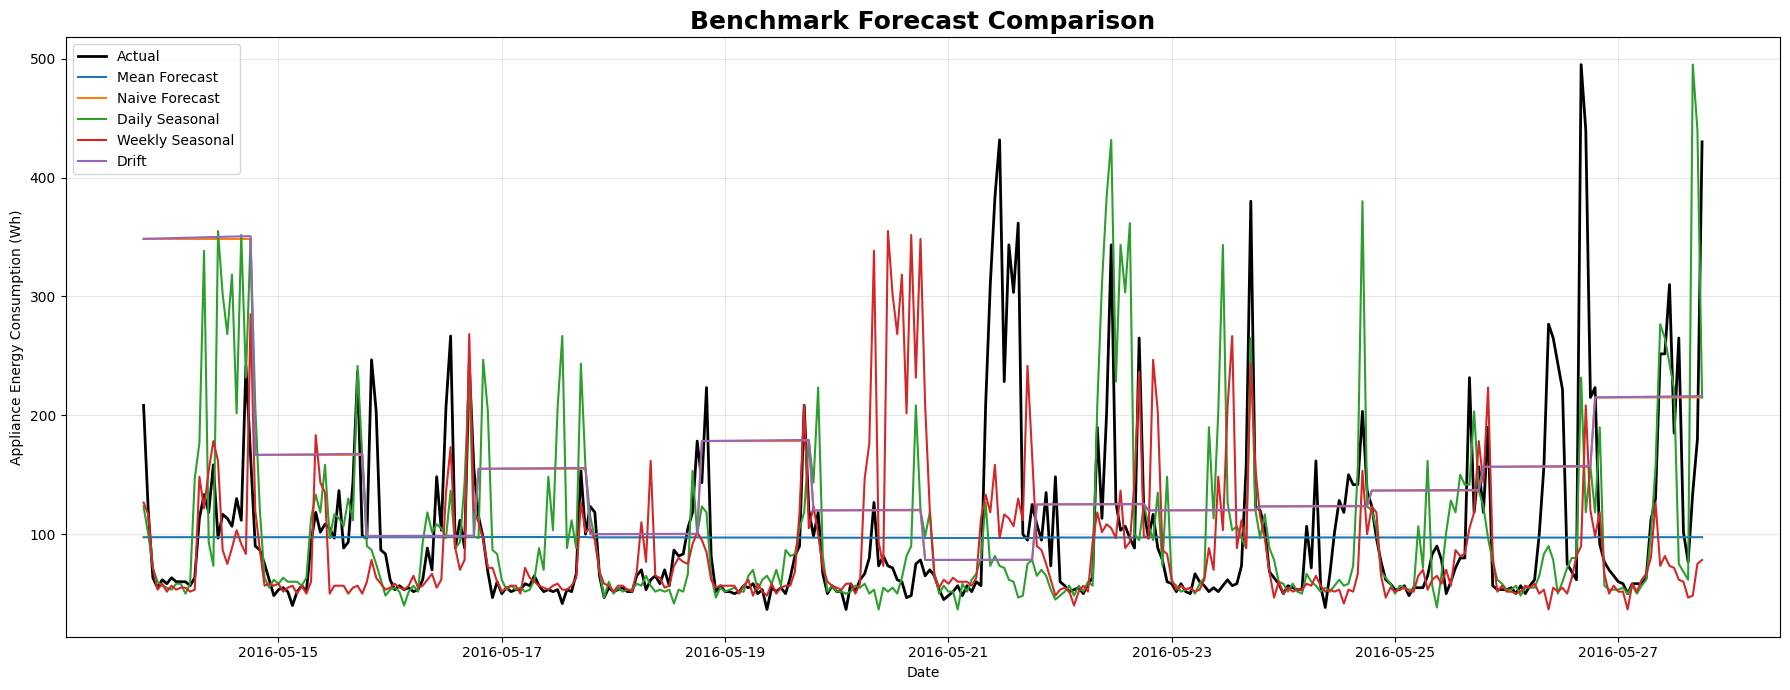

In [14]:
plt.figure(figsize=(18,7))

plt.plot(
    test.index,
    actual_daily,
    label="Actual",
    linewidth=2,
    color="black"
)

plt.plot(
    test.index,
    pred_mean,
    label="Mean Forecast"
)

plt.plot(
    test.index,
    pred_naive,
    label="Naive Forecast"
)

plt.plot(
    test.index,
    pred_daily,
    label="Daily Seasonal"
)

plt.plot(
    test.index,
    pred_weekly,
    label="Weekly Seasonal"
)

plt.plot(
    test.index,
    pred_drift,
    label="Drift"
)

plt.title(
    "Benchmark Forecast Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Appliance Energy Consumption (Wh)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/benchmark_forecasts.png",
    dpi=300
)

plt.show()